In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from src.utils.cdc_calendar import cdc_week_info

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from sklearn.linear_model import Ridge

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
from utilsforecast.plotting import plot_series

import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})

In [3]:
def plot_diagnostics(data):
    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Innovation Residuals")
    ax = axes["acf"]
    plot_acf(data["resid"].dropna(),
        zero=False, bartlett_confint=False, auto_ylims=True, ax=ax)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")
    ax = axes["hist"]
    ax.hist(data["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

plt.rcParams["figure.figsize"] = (7, 5)
#plot_diagnostics(resid)

In [4]:
norm_google_trends_ili = pd.read_csv("data/weekly_norm_google_trends_ili.csv")
norm_google_trends_ili

,ds,contagious flu,fever and flu,flu,flu cold,flu symptoms,flu type A,how long does flu last,tamiflu side effects,the flu,ili,YEAR,WEEK
0,2022-01-02,0.071211,0.561310,1.328158,2.590927,1.509332,-0.061910,0.692052,-0.241743,1.189595,4.299140,2022.0,1.0
1,2022-01-09,-0.141077,0.344531,0.562166,1.124574,0.790980,-0.182544,0.149714,-0.360198,0.608770,3.500990,2022.0,2.0
2,2022-01-16,-0.353364,-0.233548,-0.149112,0.269201,0.072627,-0.423811,-0.175688,-0.419425,0.027944,2.774570,2022.0,3.0
3,2022-01-23,-0.424127,-0.594847,-0.313253,-0.280681,-0.235238,-0.423811,-0.338390,-0.537880,-0.146304,2.054640,2022.0,4.0
4,2022-01-30,-0.494889,-0.594847,-0.532107,-0.708368,-0.389171,-0.604762,-0.446857,-0.419425,-0.436716,1.667440,2022.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,2026-07-19,-0.717083,-0.792116,-0.963798,-1.063958,-0.851995,-0.830347,-0.886693,-0.666404,-0.845617,0.871557,2026.0,29.0
238,2026-07-26,-0.729113,-0.887499,-0.962157,-1.015080,-0.785291,-0.735046,-0.893743,-0.632644,-0.793343,0.866590,2026.0,30.0
239,2026-08-02,-0.732651,-0.877383,-0.897595,-1.068846,-0.467677,-0.730824,-0.887235,-0.658112,-0.672531,0.871083,2026.0,31.0
240,2026-08-09,-0.712130,-0.814517,-0.809506,-0.838507,-0.761688,-0.791141,-0.836256,-0.623760,-0.619096,0.940307,2026.0,32.0


In [5]:
# Check why the plotted series ends early
tmp = norm_google_trends_ili.sort_values("ds").copy()
tmp["ds"] = pd.to_datetime(tmp["ds"])

#taking the missig value out
tmp = tmp.loc[tmp["ili"].notna()]

print(tmp[["ds", "ili"]].tail(6))
print("\nRows with missing ILI:")
print(tmp.loc[tmp["ili"].isna(), ["ds", "ili", "YEAR", "WEEK"]])

            ds       ili
235 2026-07-05  0.941589
236 2026-07-12  0.903223
237 2026-07-19  0.871557
238 2026-07-26  0.866590
239 2026-08-02  0.871083
240 2026-08-09  0.940307

Rows with missing ILI:
Empty DataFrame
Columns: [ds, ili, YEAR, WEEK]
Index: []


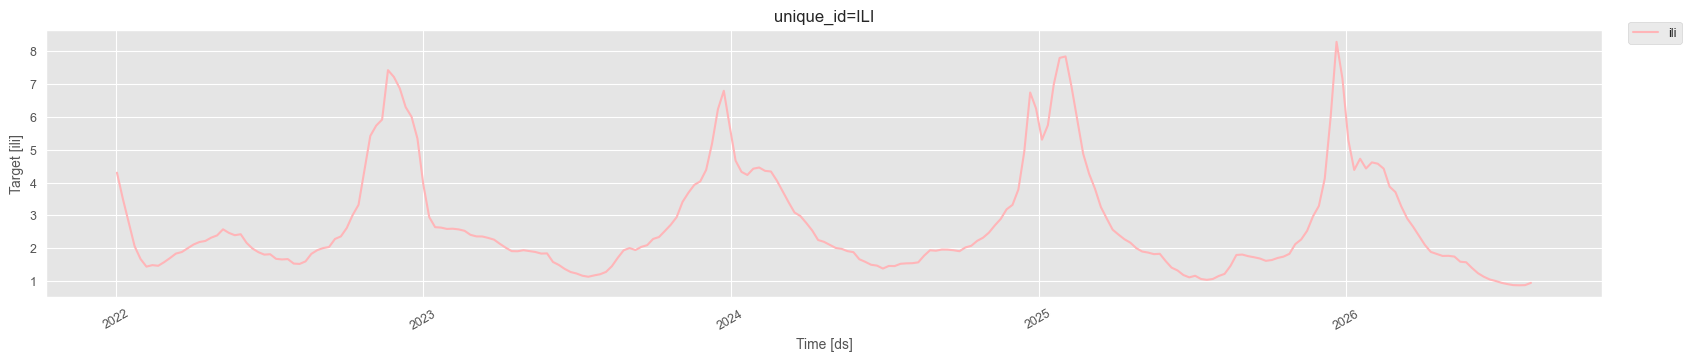

In [6]:
#We have only one ts
plot_series(
    df=tmp.assign(unique_id="ILI"),
    id_col="unique_id",
    time_col="ds",
    target_col="ili"
)

# Checking the seasonal trend

In [7]:
import plotly.graph_objects as go
import seaborn as sns

df = tmp.assign(
    Year=tmp["ds"].dt.year,
    Week=tmp["ds"].dt.isocalendar().week.astype(int),
)

unique_years = sorted(df["Year"].unique())
palette = sns.color_palette("husl", n_colors=len(unique_years))

fig = go.Figure()

# --- Background years (coloured, thin, lower opacity) ---
for i, year in enumerate(unique_years):
    if year in (2023, 2024, 2025, 2026):
        continue  # handled separately below
    subset = df[df["Year"] == year].sort_values("Week").dropna(subset=["ili"])
    r, g, b = [int(c * 255) for c in palette[i]]
    colour = f"rgb({r},{g},{b})"
    fig.add_trace(go.Scatter(
        x=subset["Week"],
        y=subset["ili"],
        mode="lines",
        name=str(year),
        line=dict(color=colour, width=1.5),
        opacity=0.5,
        hovertemplate=f"{year} — Week %{{x}}<br>ILI: %{{y:.3f}}<extra></extra>",
    ))

# --- Weighted average: 2025×50% + 2024×30% + 2023×20% ---
WA_WEIGHTS = {2025: 0.50, 2024: 0.30, 2023: 0.20}
wa_parts = []
for yr, w in WA_WEIGHTS.items():
    s = df[df["Year"] == yr][["Week", "ili"]].dropna().set_index("Week")["ili"] * w
    wa_parts.append(s)
wa = sum(wa_parts).reset_index()
wa.columns = ["Week", "ili"]

fig.add_trace(go.Scatter(
    x=wa["Week"],
    y=wa["ili"],
    mode="lines",
    name="Wtd Avg (50/30/20)",
    line=dict(color="dimgray", width=2.5, dash="dash"),
    hovertemplate="Wtd Avg — Week %{x}<br>ILI: %{y:.3f}<extra></extra>",
))

# --- 2023, 2024, 2025 individually (coloured) ---
highlight = {2023: 0.20, 2024: 0.30, 2025: 0.50}
for yr in [2023, 2024, 2025]:
    i = unique_years.index(yr)
    r, g, b = [int(c * 255) for c in palette[i]]
    colour = f"rgb({r},{g},{b})"
    subset = df[df["Year"] == yr].sort_values("Week").dropna(subset=["ili"])
    fig.add_trace(go.Scatter(
        x=subset["Week"],
        y=subset["ili"],
        mode="lines+markers",
        name=f"{yr} ({int(highlight[yr]*100)}%)",
        line=dict(color=colour, width=2),
        marker=dict(size=4),
        hovertemplate=f"{yr} — Week %{{x}}<br>ILI: %{{y:.3f}}<extra></extra>",
    ))

# --- 2026: black, bold ---
s26 = df[df["Year"] == 2026].sort_values("Week").dropna(subset=["ili"])
if not s26.empty:
    fig.add_trace(go.Scatter(
        x=s26["Week"],
        y=s26["ili"],
        mode="lines+markers",
        name="2026 (Actual)",
        line=dict(color="black", width=3),
        marker=dict(size=6, color="black"),
        hovertemplate="2026 — Week %{x}<br>ILI: %{y:.3f}<extra></extra>",
    ))

fig.update_layout(
    title="Seasonal Plot: ILI by Week of Year<br><sup>Click legend entries to show/hide; double-click to isolate</sup>",
    xaxis_title="Week of Year",
    yaxis_title="ILI",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(title="Year", x=1.01, y=1.0, xanchor="left"),
    margin=dict(r=120),
)
fig.show()


In [8]:
stl = STL(tmp["ili"], period=12)
res = stl.fit()
dcmp = pd.DataFrame({
    "ds": tmp["ds"],
    "data": tmp["ili"],
    "trend": res.trend,
    "seasonal": res.seasonal,
    "remainder": res.resid,
}).reset_index(drop=True)

dcmp.tail()

,ds,data,trend,seasonal,remainder
236,2026-07-12,0.903223,0.977223,-0.194880,0.120881
237,2026-07-19,0.871557,0.909250,-0.098812,0.061119
238,2026-07-26,0.866590,0.842904,0.000460,0.023226
239,2026-08-02,0.871083,0.778008,0.100355,-0.007280
240,2026-08-09,0.940307,0.714380,0.129307,0.096620


## Decomposition

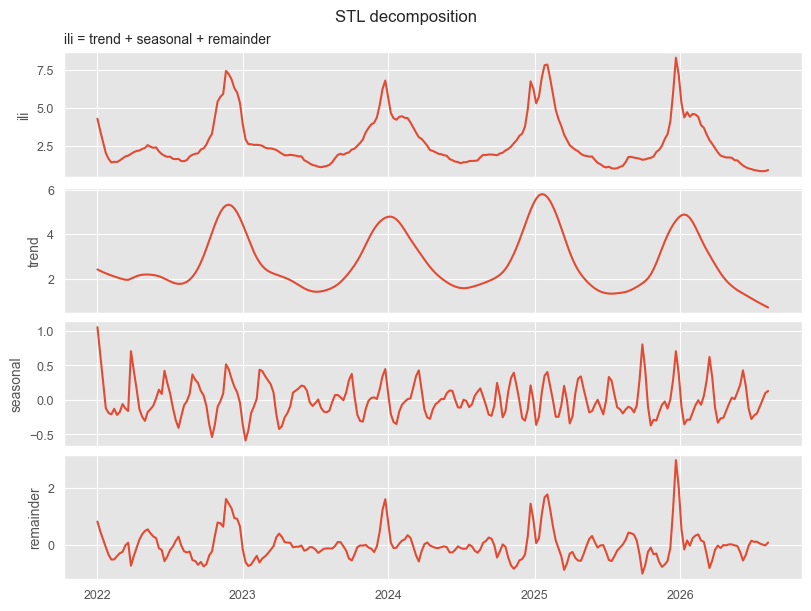

In [9]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("ili = trend + seasonal + remainder",
    size="medium", loc="left")
axes[0].set(ylabel="ili")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

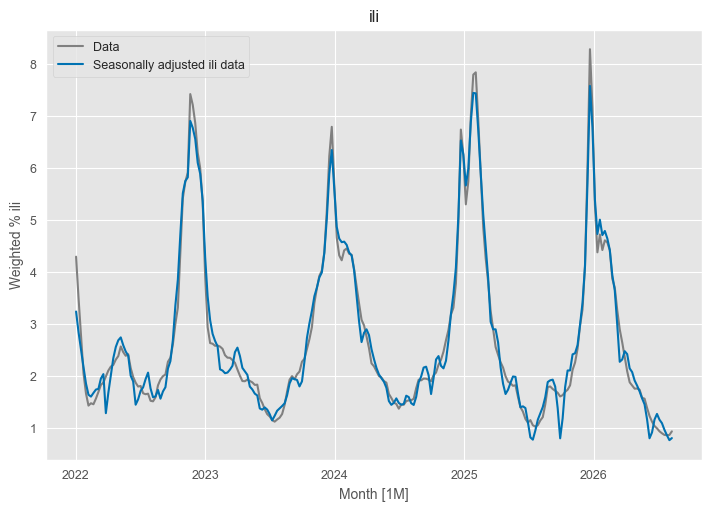

In [10]:
df = dcmp.assign(adj=lambda x: x["data"] - x["seasonal"])
fig, ax = plt.subplots()
sns.lineplot(data=df, x="ds", y="data", color="gray", label="Data")
sns.lineplot(data=df, x="ds", y="adj",
    color="#0072B2", label="Seasonally adjusted ili data")
ax.set(
    title="ili",
    xlabel="Month [1M]",
    ylabel="Weighted % ili",
)
plt.show()

## Selecting ARIMA parameter
- When there are long seasonal periods, a dynamic regression with Fourier terms
  - weekly data has seasonal period of approximately 52
- A harmonic regression approach where the seasonal pattern is modelled using Fourier terms with short-term time series dynamics handled by an ARMA error
  - The advantages of this approach are:
        - it allows any length seasonality;
        - for data with more than one seasonal period, Fourier terms of different frequencies can be included;
            - the smoothness of the seasonal pattern can be controlled by K, the number of Fourier sin and cos pairs 
            - the seasonal pattern is smoother for smaller values of K
            - the short-term dynamics are easily handled with a simple ARMA error

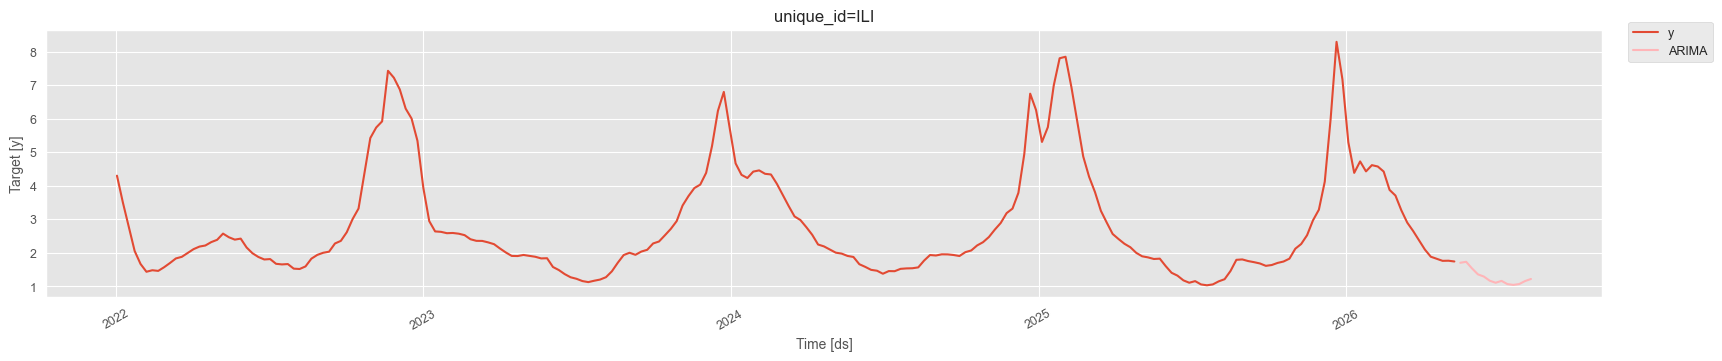

In [11]:

from statsforecast import StatsForecast
from statsforecast.models import ARIMA

# ── Fixed ARIMA(2,0,1)(0,1,0)[52] ────────────────────────────────────────────
# Order derived from AutoARIMA selection: arma = (2, 1, 0, 0, 52, 0, 1)
#   [p, q, P, Q, m, d, D] → ARIMA(p=2, d=0, q=1)(P=0, D=1, Q=0)[52]
# ─────────────────────────────────────────────────────────────────────────────

H = 13
data_sf = (tmp[["ds", "ili"]]
              .rename(columns={"ili": "y"})
              .assign(unique_id="ILI")
              .dropna(subset=["y"])
              .sort_values("ds")
              .reset_index(drop=True)
              [["unique_id", "ds", "y"]])   # keep only the 3 required columns

train_sf = data_sf.iloc[:-H]
test_sf  = data_sf.iloc[-H:]

sf = StatsForecast(
    models=[ARIMA(order=(2, 0, 1), season_length=52, seasonal_order=(0, 1, 0))],
    freq="W",
    n_jobs=1,
)
sf.fit(train_sf)
fcasts = sf.predict(h=H, level=[80, 95])

plot_series(
    df=train_sf,
    forecasts_df=fcasts,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
)


## hyper parameter tuning

In [12]:

# # ── Optimal K selection for ARIMAFourier ──────────────────────────────────────
# # Method 1 — AIC on the full training series (fast, in-sample)
# # Method 2 — backtest MAE on a hold-out window (more reliable)
# # Rule of thumb for weekly ILI: K=2 or 3 captures the main flu-season shape
# # without overfitting the ARIMA residuals.
# # ─────────────────────────────────────────────────────────────────────────────

# from statsmodels.tsa.statespace.sarimax import SARIMAX as _SARIMAX
# import numpy as np
# import pandas as pd

# # Full series used for AIC comparison (drop NaN)
# aic_series = (tmp[["ds", "ili"]]
#               .dropna(subset=["ili"])
#               .sort_values("ds")
#               .reset_index(drop=True))
# y_full = aic_series["ili"].values
# n_full = len(y_full)

# def _fourier_mat(t_indices, m, K):
#     t = np.array(t_indices, dtype=float)
#     cols = []
#     for j in range(1, K + 1):
#         cols.append(np.cos(2 * np.pi * j * t / m))
#         if j != m / 2:
#             cols.append(np.sin(2 * np.pi * j * t / m))
#     return np.column_stack(cols)

# # ── Method 1: AIC sweep ───────────────────────────────────────────────────────
# print("K   AIC        BIC        n_params")
# print("-" * 40)
# aic_rows = []
# for K in range(1, 11):
#     exog = _fourier_mat(range(n_full), 52, K)
#     try:
#         res = _SARIMAX(y_full, order=(2,0,1), seasonal_order=(0,1,0,52),
#                        exog=exog, enforce_stationarity=False,
#                        enforce_invertibility=False).fit(disp=False)
#         aic_rows.append({"K": K, "AIC": round(res.aic, 1),
#                          "BIC": round(res.bic, 1), "n_params": res.df_model})
#         print(f"{K:2d}  {res.aic:10.1f}  {res.bic:10.1f}  {res.df_model}")
#     except Exception as e:
#         print(f"{K:2d}  ERROR: {e}")

# aic_df = pd.DataFrame(aic_rows)
# best_aic_K = int(aic_df.loc[aic_df["AIC"].idxmin(), "K"])
# best_bic_K = int(aic_df.loc[aic_df["BIC"].idxmin(), "K"])
# print(f"\nBest K by AIC: {best_aic_K}  |  Best K by BIC: {best_bic_K}")

# # ── Method 2: backtest MAE for K=1..6 on rolling_fcasts ──────────────────────
# # (only runs if rolling_fcasts already has ARIMAFourier columns in memory)
# print("\n── Backtest MAE from rolling_fcasts (if available) ──────────────────")
# actuals_map = all_data.set_index("ds")["ili"].to_dict()
# for K in range(1, 7):
#     col = f"ARIMAFourier_K{K}" if f"ARIMAFourier_K{K}" in rolling_fcasts.columns else "ARIMAFourier"
#     if col not in rolling_fcasts.columns:
#         continue
#     tmp_rf = rolling_fcasts[["ds", col]].copy()
#     tmp_rf["actual"] = tmp_rf["ds"].map(actuals_map)
#     mae = (tmp_rf["actual"] - tmp_rf[col]).abs().mean()
#     print(f"  K={K}: MAE = {mae:.4f}")

# print(f"\nRecommendation: set FOURIER_K = {best_bic_K} in the rolling forecast cell")
# print("(BIC penalises complexity more — better for small weekly ILI datasets)")


In [13]:

# # ── Joint ARIMA order + K selection for ARIMAFourier ─────────────────────────
# # Uses pmdarima.auto_arima with Fourier exog — equivalent to R's
# #   auto.arima(y, xreg = fourier(y, K=K), D=1)
# # Sweeps K=1..6 and picks the (order, K) pair with lowest AIC.
# # This cell about one hour to run
# # ─────────────────────────────────────────────────────────────────────────────

# import pmdarima as pm
# import numpy as np
# import pandas as pd

# #y_sel = (all_data["ili"].values
# #         if "all_data" in dir() else
# #         tmp["ili"].dropna().values)
# #n_sel = len(y_sel)

# def _fourier(t_indices, m, K):
#     t = np.array(t_indices, dtype=float)
#     cols = []
#     for j in range(1, K + 1):
#         cols.append(np.cos(2 * np.pi * j * t / m))
#         if j != m / 2:
#             cols.append(np.sin(2 * np.pi * j * t / m))
#     return np.column_stack(cols)

# print(f"{'K':>3}  {'order (p,d,q)':>14}  {'seasonal (P,D,Q)':>16}  {'AIC':>10}  {'BIC':>10}")
# print("-" * 62)

# rows = []
# for K in range(1, 7):
#     exog = _fourier(range(n_sel), 52, K)
#     try:
#         mdl = pm.auto_arima(
#             y_sel,
#             X=exog,
#             seasonal=True, m=52,
#             D=1,                    # fix seasonal differencing to 1
#             max_p=4, max_q=4,
#             #max_P=2, max_Q=2,
#             max_P=0, max_Q=0,
#             information_criterion="aic",
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore",
#         )
#         rows.append({
#             "K": K,
#             "order":          mdl.order,
#             "seasonal_order": mdl.seasonal_order[:3],
#             "AIC": round(mdl.aic(), 1),
#             "BIC": round(mdl.bic(), 1),
#         })
#         print(f"{K:>3}  {str(mdl.order):>14}  {str(mdl.seasonal_order[:3]):>16}"
#               f"  {mdl.aic():>10.1f}  {mdl.bic():>10.1f}")
#     except Exception as e:
#         print(f"{K:>3}  ERROR: {e}")

# res_df = pd.DataFrame(rows)
# best   = res_df.loc[res_df["AIC"].idxmin()]
# print(f"\n★  Best by AIC: K={int(best.K)}, "
#       f"ARIMA{best.order}×{best.seasonal_order}[52]")
# print(f"\nUpdate ARIMAFourier in the rolling forecast cell:")
# p, d, q = best.order
# P, D, Q = best.seasonal_order
# print(f"  order=({p}, {d}, {q}), season_length=52, seasonal_order=({P}, {D}, {Q})")
# print(f"  FOURIER_K = {int(best.K)}")


## Models

|Model|	What it does|
|:----|:------------|
|WtdSeasonalNaive| Use custome weight and previous three years to make predictions|
|MSTL | Multiple Seasonal-Trend decomposition using Loess. Decompse data into trend, seasonal component and remainder.  Make prediction and recombine|
|TSLM | Use trend() and Seasonality() to make prediction|
|TSLMDiff| Target is $\triangle \text{ili}$, debiased via differencing|
|TSLMFourier| Using Fourier as features to making prediction|
|TSLMFourierDiff|Target is $\triangle \text{ili}$, debiased via differencing|
|ARIMA|	ARIMA(2,0,1)(0,1,0)[52] — pure time-series dynamics|
|ARIMAFourier|	Update ARIMAFourier in the rolling forecast cell order=(0, 1, 0), season_length=52, seasonal_order=(0, 1, 1) FOURIER_K = 4.  ★  Best by AIC: K=4, ARIMA(0, 1, 0)×(0, 1, 1)[52]|



## Fit the model


In [14]:

# ── Expanding-window rolling forecast with prediction intervals ───────────────
# Fixed start: 2023-01-01.  Initial train ends: 2025-07-01.  Takes less than 12 min
# ─────────────────────────────────────────────────────────────────────────────

from statsforecast import StatsForecast
from statsforecast.models import AutoETS, ARIMA, MSTL, SeasonalNaive
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX as _SARIMAX
import plotly.graph_objects as go
import numpy as np

# ── Custom: Weighted Seasonal Naive (50/30/20%) ───────────────────────────────
class WtdSeasonalNaive:
    _WEIGHTS = [0.50, 0.30, 0.20]
    def __init__(self, season_length=52, alias="WtdSeasonalNaive"):
        self.season_length = season_length; self.alias = alias
    def fit(self, y, X=None):
        self._y = np.asarray(y, dtype=float); return self
    def predict(self, h, X=None, level=None):
        m, n  = self.season_length, len(self._y)
        preds = np.full(h, np.nan)
        for i in range(h):
            refs  = [self._y[n-k*m+i] if (n-k*m+i)>=0 else np.nan for k in [1,2,3]]
            valid = [(v,w) for v,w in zip(refs,self._WEIGHTS) if not np.isnan(v)]
            tw    = sum(w for _,w in valid)
            preds[i] = sum(v*w/tw for v,w in valid) if valid else np.nan
        result = {"mean": preds}
        if level is not None:
            std = float(np.nanstd(np.diff(self._y)))
            for lv in level:
                z = {80:1.282,95:1.645}.get(int(lv),1.96)
                ci = z*std*np.sqrt(np.arange(1,h+1))
                result[f"lo-{lv}"] = preds-ci; result[f"hi-{lv}"] = preds+ci
        return result
    def __repr__(self): return self.alias

# ── Custom: TSLM  y ~ trend() + season() (levels) ────────────────────────────
class TSLM:
    """Fit on levels. May over-predict if ILI has trended down over history."""
    def __init__(self, season_length=52, alias="TSLM"):
        self.season_length = season_length; self.alias = alias

    @staticmethod
    def _build_X(t_indices, m):
        n = len(t_indices); seas = np.zeros((n, m - 1))
        for i, t in enumerate(t_indices):
            s = int(t) % m
            if s < m - 1: seas[i, s] = 1
        return np.hstack([np.array(t_indices, dtype=float).reshape(-1, 1), seas])

    def fit(self, y, X=None):
        self._y   = np.asarray(y, dtype=float); self._n = len(self._y)
        Xt        = self._build_X(range(self._n), self.season_length)
        self._lr  = LinearRegression(fit_intercept=True); self._lr.fit(Xt, self._y)
        resid     = self._y - self._lr.predict(Xt)
        self._std = float(np.std(resid, ddof=Xt.shape[1]+1)); return self

    def predict(self, h, X=None, level=None):
        preds  = self._lr.predict(self._build_X(range(self._n, self._n+h), self.season_length))
        result = {"mean": preds}
        if level is not None:
            for lv in level:
                z = {80:1.282,95:1.645}.get(int(lv),1.96)
                ci = z*self._std*np.sqrt(np.arange(1,h+1))
                result[f"lo-{lv}"] = preds-ci; result[f"hi-{lv}"] = preds+ci
        return result

    def __repr__(self): return self.alias

# ── Custom: TSLMDiff  Δy ~ trend() + season() (differenced) ──────────────────
class TSLMDiff:
    """Fit on first-differences to remove trend bias; cumsum back to levels."""
    def __init__(self, season_length=52, alias="TSLMDiff"):
        self.season_length = season_length; self.alias = alias

    @staticmethod
    def _build_X(t_indices, m):
        n = len(t_indices); seas = np.zeros((n, m - 1))
        for i, t in enumerate(t_indices):
            s = int(t) % m
            if s < m - 1: seas[i, s] = 1
        return np.hstack([np.array(t_indices, dtype=float).reshape(-1, 1), seas])

    def fit(self, y, X=None):
        self._y    = np.asarray(y, dtype=float); self._n = len(self._y)
        self._last = self._y[-1]
        dy         = np.diff(self._y)
        Xt         = self._build_X(range(1, self._n), self.season_length)
        self._lr   = LinearRegression(fit_intercept=True); self._lr.fit(Xt, dy)
        resid      = dy - self._lr.predict(Xt)
        self._std  = float(np.std(resid, ddof=Xt.shape[1]+1)); return self

    def predict(self, h, X=None, level=None):
        Xf      = self._build_X(range(self._n, self._n+h), self.season_length)
        d_preds = self._lr.predict(Xf)
        preds   = self._last + np.cumsum(d_preds)
        result  = {"mean": preds}
        if level is not None:
            for lv in level:
                z = {80:1.282,95:1.645}.get(int(lv),1.96)
                ci = z*self._std*np.sqrt(np.arange(1,h+1))
                result[f"lo-{lv}"] = preds-ci; result[f"hi-{lv}"] = preds+ci
        return result

    def __repr__(self): return self.alias

# ── Custom: TSLMFourier  y ~ trend() + fourier(K) (levels) ───────────────────
class TSLMFourier:
    """Fit on levels. May over-predict if ILI has trended down over history."""
    def __init__(self, season_length=52, K=3, alias="TSLMFourier"):
        self.season_length = season_length; self.K = K; self.alias = alias

    def _build_X(self, t_indices):
        m, K = self.season_length, self.K; t = np.array(t_indices, dtype=float)
        cols = [t]
        for j in range(1, K+1):
            cols.append(np.cos(2*np.pi*j*t/m))
            if j != m/2: cols.append(np.sin(2*np.pi*j*t/m))
        return np.column_stack(cols)

    def fit(self, y, X=None):
        self._y = np.asarray(y, dtype=float); self._n = len(self._y)
        Xt = self._build_X(range(self._n))
        self._lr = LinearRegression(fit_intercept=True); self._lr.fit(Xt, self._y)
        resid = self._y - self._lr.predict(Xt)
        self._std = float(np.std(resid, ddof=Xt.shape[1]+1)); return self

    def predict(self, h, X=None, level=None):
        preds  = self._lr.predict(self._build_X(range(self._n, self._n+h)))
        result = {"mean": preds}
        if level is not None:
            for lv in level:
                z = {80:1.282,95:1.645}.get(int(lv),1.96)
                ci = z*self._std*np.sqrt(np.arange(1,h+1))
                result[f"lo-{lv}"] = preds-ci; result[f"hi-{lv}"] = preds+ci
        return result

    def __repr__(self): return self.alias

# ── Custom: TSLMFourierDiff  Δy ~ trend() + fourier(K) (differenced) ─────────
class TSLMFourierDiff:
    """Fit on first-differences to remove trend bias; cumsum back to levels."""
    def __init__(self, season_length=52, K=3, alias="TSLMFourierDiff"):
        self.season_length = season_length; self.K = K; self.alias = alias

    def _build_X(self, t_indices):
        m, K = self.season_length, self.K; t = np.array(t_indices, dtype=float)
        cols = [t]
        for j in range(1, K+1):
            cols.append(np.cos(2*np.pi*j*t/m))
            if j != m/2: cols.append(np.sin(2*np.pi*j*t/m))
        return np.column_stack(cols)

    def fit(self, y, X=None):
        self._y    = np.asarray(y, dtype=float); self._n = len(self._y)
        self._last = self._y[-1]
        dy         = np.diff(self._y)
        Xt         = self._build_X(range(1, self._n))
        self._lr   = LinearRegression(fit_intercept=True); self._lr.fit(Xt, dy)
        resid      = dy - self._lr.predict(Xt)
        self._std  = float(np.std(resid, ddof=Xt.shape[1]+1)); return self

    def predict(self, h, X=None, level=None):
        d_preds = self._lr.predict(self._build_X(range(self._n, self._n+h)))
        preds   = self._last + np.cumsum(d_preds)
        result  = {"mean": preds}
        if level is not None:
            for lv in level:
                z = {80:1.282,95:1.645}.get(int(lv),1.96)
                ci = z*self._std*np.sqrt(np.arange(1,h+1))
                result[f"lo-{lv}"] = preds-ci; result[f"hi-{lv}"] = preds+ci
        return result

    def __repr__(self): return self.alias

# ── Custom: ARIMAFourier — ARIMA(0,1,0)(0,1,1)[52] + Fourier(K=4) ────────────
class ARIMAFourier:
    """Best by AIC: K=4, ARIMA(0,1,0)×(0,1,1)[52]"""
    def __init__(self, season_length=52, K=4, alias="ARIMAFourier"):
        self.season_length = season_length; self.K = K; self.alias = alias

    def _fourier(self, t_indices):
        m, K = self.season_length, self.K; t = np.array(t_indices, dtype=float)
        cols = []
        for j in range(1, K+1):
            cols.append(np.cos(2*np.pi*j*t/m))
            if j != m/2: cols.append(np.sin(2*np.pi*j*t/m))
        return np.column_stack(cols)

    def fit(self, y, X=None):
        self._y = np.asarray(y, dtype=float); self._n = len(self._y)
        self._model = _SARIMAX(
            self._y, order=(0,1,0), seasonal_order=(0,1,1,self.season_length),
            exog=self._fourier(range(self._n)),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False); return self

    def predict(self, h, X=None, level=None):
        fc    = self._model.get_forecast(steps=h, exog=self._fourier(range(self._n, self._n+h)))
        preds = np.asarray(fc.predicted_mean)
        result = {"mean": preds}
        if level is not None:
            for lv in level:
                ci = fc.conf_int(alpha=1-lv/100)
                result[f"lo-{lv}"] = np.asarray(ci)[:,0]
                result[f"hi-{lv}"] = np.asarray(ci)[:,1]
        return result

    def __repr__(self): return self.alias


# ── Rolling forecast loop ─────────────────────────────────────────────────────
H           = 13
TRAIN_START = "2023-01-01"
INITIAL_END = "2025-07-01"
FOURIER_K   = 3

all_data = (
    tmp.loc[tmp["ds"] >= TRAIN_START, ["ds", "ili"]]
    .dropna(subset=["ili"])
    .sort_values("ds")
    .reset_index(drop=True)
)
all_data["ds"] = pd.to_datetime(all_data["ds"])

init_end_idx   = all_data[all_data["ds"] <= pd.Timestamp(INITIAL_END)].index.max()
all_forecasts  = []
window_end_idx = init_end_idx

while window_end_idx < len(all_data) - 1:
    train_win    = all_data.iloc[:window_end_idx + 1]
    train_sf_win = (train_win[["ds", "ili"]]
                    .rename(columns={"ili": "y"})
                    .assign(unique_id="ILI")
                    [["unique_id", "ds", "y"]])

    sf_win = StatsForecast(
        models=[
            ARIMA(order=(2,0,1), season_length=52, seasonal_order=(0,1,0)),
            MSTL(season_length=[52], trend_forecaster=AutoETS(model="ZZN")),
            SeasonalNaive(season_length=52),
        ],
        freq="W", n_jobs=1,
    )
    sf_win.fit(train_sf_win)
    sf_preds = sf_win.predict(h=H, level=[80, 95])

    for m in [WtdSeasonalNaive(52),
              TSLM(52), TSLMDiff(52),
              TSLMFourier(52, K=FOURIER_K), TSLMFourierDiff(52, K=FOURIER_K),
              ARIMAFourier(52, K=4)]:
        nm = repr(m); m.fit(train_win["ili"].values); out = m.predict(h=H, level=[80, 95])
        sf_preds[nm] = out["mean"]
        for lv in ["lo-80","hi-80","lo-95","hi-95"]: sf_preds[f"{nm}-{lv}"] = out[lv]

    sf_preds["train_cutoff"] = train_win["ds"].iloc[-1]
    all_forecasts.append(sf_preds)
    window_end_idx = min(window_end_idx + H, len(all_data) - 1)

rolling_fcasts = pd.concat(all_forecasts, ignore_index=True)
print(f"Cutoffs: {rolling_fcasts['train_cutoff'].nunique()}  |  Total rows: {len(rolling_fcasts)}")
print("Columns:", rolling_fcasts.columns.tolist())


c:\Users\rahul.nandi\AppData\Local\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\rahul.nandi\AppData\Local\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\rahul.nandi\AppData\Local\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\rahul.nandi\AppD

Cutoffs: 5  |  Total rows: 65
Columns: ['unique_id', 'ds', 'ARIMA', 'ARIMA-lo-95', 'ARIMA-lo-80', 'ARIMA-hi-80', 'ARIMA-hi-95', 'MSTL', 'MSTL-lo-95', 'MSTL-lo-80', 'MSTL-hi-80', 'MSTL-hi-95', 'SeasonalNaive', 'SeasonalNaive-lo-80', 'SeasonalNaive-lo-95', 'SeasonalNaive-hi-80', 'SeasonalNaive-hi-95', 'WtdSeasonalNaive', 'WtdSeasonalNaive-lo-80', 'WtdSeasonalNaive-hi-80', 'WtdSeasonalNaive-lo-95', 'WtdSeasonalNaive-hi-95', 'TSLM', 'TSLM-lo-80', 'TSLM-hi-80', 'TSLM-lo-95', 'TSLM-hi-95', 'TSLMDiff', 'TSLMDiff-lo-80', 'TSLMDiff-hi-80', 'TSLMDiff-lo-95', 'TSLMDiff-hi-95', 'TSLMFourier', 'TSLMFourier-lo-80', 'TSLMFourier-hi-80', 'TSLMFourier-lo-95', 'TSLMFourier-hi-95', 'TSLMFourierDiff', 'TSLMFourierDiff-lo-80', 'TSLMFourierDiff-hi-80', 'TSLMFourierDiff-lo-95', 'TSLMFourierDiff-hi-95', 'ARIMAFourier', 'ARIMAFourier-lo-80', 'ARIMAFourier-hi-80', 'ARIMAFourier-lo-95', 'ARIMAFourier-hi-95', 'train_cutoff']


In [15]:

# ── Slider backtest: all 9 models vs Actual ───────────────────────────────────
# Diff variants (TSLMDiff, TSLMFourierDiff) use first-differenced target
# to remove trend bias. Compare against level-fit counterparts.
# ─────────────────────────────────────────────────────────────────────────────

def hex_rgba(hex_color, alpha):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

MODELS = ["ARIMA", "ARIMAFourier", "MSTL", "SeasonalNaive",
          "WtdSeasonalNaive",
          "TSLM", "TSLMDiff",
          "TSLMFourier", "TSLMFourierDiff"]
MODEL_COLORS = {
    "ARIMA":            "#2ca02c",
    "ARIMAFourier":     "#1f77b4",
    "MSTL":             "#ff7f0e",
    "SeasonalNaive":    "#d62728",
    "WtdSeasonalNaive": "#9467bd",
    "TSLM":             "#17becf",
    "TSLMDiff":         "#0a6480",   # darker teal — diff version of TSLM
    "TSLMFourier":      "#e377c2",
    "TSLMFourierDiff":  "#8c1f6e",   # darker pink — diff version of TSLMFourier
}

cutoffs_plot     = sorted(rolling_fcasts["train_cutoff"].unique())
cutoff_strs_plot = [pd.Timestamp(c).strftime("%Y-%m-%d") for c in cutoffs_plot]
n_cutoffs_plot   = len(cutoffs_plot)

actual_start_plot = pd.Timestamp(cutoffs_plot[0]) - pd.Timedelta(weeks=4)
actual_plot  = all_data[all_data["ds"] >= actual_start_plot].sort_values("ds")
default_sub  = rolling_fcasts[rolling_fcasts["train_cutoff"] == cutoffs_plot[0]].sort_values("ds")

def _band_traces(sub, model, colour):
    def _y(col): return sub[col].values if col in sub.columns else sub[model].values
    x = sub["ds"].values
    return [
        go.Scatter(x=x, y=_y(f"{model}-lo-95"), mode="lines", line=dict(width=0),
                   legendgroup=model, showlegend=False, hoverinfo="skip", name=f"{model} lo95"),
        go.Scatter(x=x, y=_y(f"{model}-hi-95"), mode="lines", line=dict(width=0),
                   fill="tonexty", fillcolor=hex_rgba(colour, 0.15),
                   legendgroup=model, showlegend=False, hoverinfo="skip", name=f"{model} hi95"),
        go.Scatter(x=x, y=_y(f"{model}-lo-80"), mode="lines", line=dict(width=0),
                   legendgroup=model, showlegend=False, hoverinfo="skip", name=f"{model} lo80"),
        go.Scatter(x=x, y=_y(f"{model}-hi-80"), mode="lines", line=dict(width=0),
                   fill="tonexty", fillcolor=hex_rgba(colour, 0.30),
                   legendgroup=model, showlegend=False, hoverinfo="skip", name=f"{model} hi80"),
        go.Scatter(x=x, y=sub[model].values, mode="lines+markers", name=model,
                   legendgroup=model, showlegend=True,
                   line=dict(color=colour, width=2,
                             dash="solid" if model.endswith("Diff") else "dot"),
                   marker=dict(size=5), connectgaps=False,
                   hovertemplate=f"{model}<br>Week: %{{x}}<br>ILI: %{{y:.3f}}<extra></extra>"),
    ]

fig_slider = go.Figure()
fig_slider.add_trace(go.Scatter(
    x=actual_plot["ds"], y=actual_plot["ili"],
    mode="lines+markers", name="Actual", legendgroup="Actual", showlegend=True,
    line=dict(color="black", width=2.5), marker=dict(size=6),
))
for model in MODELS:
    for t in _band_traces(default_sub, model, MODEL_COLORS[model]):
        fig_slider.add_trace(t)

frames_plot = []
for i, cutoff in enumerate(cutoffs_plot):
    sub = rolling_fcasts[rolling_fcasts["train_cutoff"] == cutoff].sort_values("ds")
    frame_data = [go.Scatter(x=actual_plot["ds"], y=actual_plot["ili"])]
    for model in MODELS:
        frame_data.extend(_band_traces(sub, model, MODEL_COLORS[model]))
    frames_plot.append(go.Frame(data=frame_data, name=cutoff_strs_plot[i]))
fig_slider.frames = frames_plot

sliders_plot = [dict(
    active=0,
    currentvalue=dict(prefix="Cutoff: ", font=dict(size=14)),
    pad=dict(t=50),
    steps=[dict(
        args=[[cutoff_strs_plot[i]],
              dict(frame=dict(duration=300, redraw=True), mode="immediate")],
        label=cutoff_strs_plot[i], method="animate",
    ) for i in range(n_cutoffs_plot)],
)]

fig_slider.update_layout(
    title=(f"Backtesting ({INITIAL_END[:7]}): 9 models (H={H} wks) vs Actual<br>"
           "<sup>Solid = differenced (Diff) variants; dotted = levels — compare bias</sup>"),
    xaxis_title="Week", yaxis_title="ILI",
    hovermode="x unified", template="plotly_white",
    sliders=sliders_plot,
    legend=dict(x=1.0, y=1.0, xanchor="right", yanchor="top",
                bgcolor="rgba(255,255,255,0.8)",
                bordercolor="rgba(0,0,0,0.3)", borderwidth=1),
    updatemenus=[dict(
        type="buttons", showactive=False, y=1.12, x=0.0, xanchor="left",
        buttons=[
            dict(label="\u25b6 Play", method="animate",
                 args=[None, dict(frame=dict(duration=500, redraw=True), fromcurrent=True)]),
            dict(label="\u23f8 Pause", method="animate",
                 args=[[None], dict(frame=dict(duration=0, redraw=True), mode="immediate")]),
        ],
    )],
)
fig_slider.show()


Dropdown(description='Model:', layout=Layout(width='320px'), options=('ARIMA', 'ARIMAFourier', 'MSTL', 'Season…

Output()

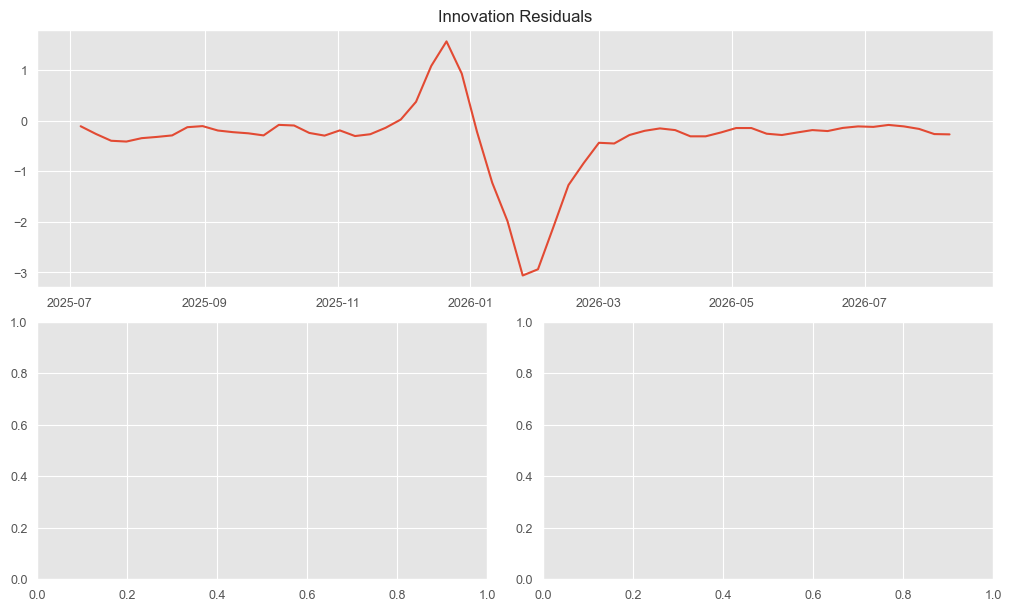

In [16]:

# ── Residual diagnostics for selected backtest model ─────────────────────────
# Pick a model from the dropdown; shows residuals across all backtest windows.
# ─────────────────────────────────────────────────────────────────────────────

import ipywidgets as widgets
from IPython.display import display

_actuals = all_data.rename(columns={"ili": "actual"})[["ds", "actual"]]
_merged  = rolling_fcasts.merge(_actuals, on="ds", how="left")

def _show_diagnostics(model_name):
    if model_name not in _merged.columns:
        print(f"Column '{model_name}' not found in rolling_fcasts.")
        return
    resid_df = (
        _merged[["ds", model_name, "actual"]]
        .dropna(subset=[model_name, "actual"])
        .assign(resid=lambda x: x["actual"] - x[model_name])
        .sort_values("ds")
        .reset_index(drop=True)
    )
    plt.rcParams["figure.figsize"] = (10, 6)
    print(f"\nResidual diagnostics — {model_name}  "
          f"(n={len(resid_df)}, "
          f"MAE={resid_df['resid'].abs().mean():.4f}, "
          f"RMSE={((resid_df['resid']**2).mean()**0.5):.4f})\n")
    plot_diagnostics(resid_df)
    plt.suptitle(f"Residual Diagnostics — {model_name}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

dropdown = widgets.Dropdown(
    options=MODELS,
    value=MODELS[0],
    description="Model:",
    layout=widgets.Layout(width="320px"),
)
out = widgets.Output()

def _on_change(change):
    if change["name"] == "value":
        out.clear_output(wait=True)
        with out:
            _show_diagnostics(change["new"])

dropdown.observe(_on_change, names="value")
display(dropdown, out)
with out:
    _show_diagnostics(MODELS[0])


### Backtesting weekly increment

- maintaine the model structure and refitting coefficients

In [17]:

# ── Weekly-increment rolling forecast (one cutoff per week) ──────────────────
# Same models as above but the training window grows by 1 week each step,
# so every week has its own 13-week forecast.  ARIMAFourier excluded.
# ─────────────────────────────────────────────────────────────────────────────

import warnings

H_W           = 13
TRAIN_START_W = "2023-01-01"
INITIAL_END_W = "2025-07-01"   # first cutoff date

all_data_w = (
    tmp.loc[tmp["ds"] >= TRAIN_START_W, ["ds", "ili"]]
    .dropna(subset=["ili"])
    .sort_values("ds")
    .reset_index(drop=True)
)
all_data_w["ds"] = pd.to_datetime(all_data_w["ds"])

init_end_w   = all_data_w[all_data_w["ds"] <= pd.Timestamp(INITIAL_END_W)].index.max()
all_fcast_w  = []
win_end_w    = init_end_w
total_steps  = len(all_data_w) - init_end_w   # include the final week as a cutoff

print(f"Running {total_steps} weekly cutoffs from "
      f"{all_data_w.loc[init_end_w, 'ds'].date()} "
      f"to {all_data_w['ds'].iloc[-1].date()} ...")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")    # suppress SARIMAX init warnings
    for step in range(total_steps):
        train_w    = all_data_w.iloc[:win_end_w + 1]
        train_sf_w = (train_w[["ds", "ili"]]
                      .rename(columns={"ili": "y"})
                      .assign(unique_id="ILI")
                      [["unique_id", "ds", "y"]])

        sf_w = StatsForecast(
            models=[
                ARIMA(order=(2, 0, 1), season_length=52, seasonal_order=(0, 1, 0)),
                MSTL(season_length=[52], trend_forecaster=AutoETS(model="ZZN")),
                SeasonalNaive(season_length=52),
            ],
            freq="W",
            n_jobs=1,
        )
        sf_w.fit(train_sf_w)
        sf_p = sf_w.predict(h=H_W, level=[80, 95])

        for m_w in [WtdSeasonalNaive(52), TSLM(52), TSLMDiff(52),
                    TSLMFourier(52, K=FOURIER_K), TSLMFourierDiff(52, K=FOURIER_K)]:
            nm_w = repr(m_w)
            m_w.fit(train_w["ili"].values)
            o_w = m_w.predict(h=H_W, level=[80, 95])
            sf_p[nm_w] = o_w["mean"]
            for lv in ["lo-80","hi-80","lo-95","hi-95"]:
                sf_p[f"{nm_w}-{lv}"] = o_w[lv]

        sf_p["train_cutoff"] = train_w["ds"].iloc[-1]
        all_fcast_w.append(sf_p)
        win_end_w += 1   # ← 1-week step

        if (step + 1) % 10 == 0:
            print(f"  {step+1}/{total_steps} done")

rolling_fcasts_w = pd.concat(all_fcast_w, ignore_index=True)
print(f"\nDone — {rolling_fcasts_w['train_cutoff'].nunique()} cutoffs, "
      f"{len(rolling_fcasts_w)} rows")
print("Columns:", rolling_fcasts_w.columns.tolist())


Running 59 weekly cutoffs from 2025-06-29 to 2026-08-09 ...
  10/59 done
  20/59 done
  30/59 done
  40/59 done
  50/59 done

Done — 59 cutoffs, 767 rows
Columns: ['unique_id', 'ds', 'ARIMA', 'ARIMA-lo-95', 'ARIMA-lo-80', 'ARIMA-hi-80', 'ARIMA-hi-95', 'MSTL', 'MSTL-lo-95', 'MSTL-lo-80', 'MSTL-hi-80', 'MSTL-hi-95', 'SeasonalNaive', 'SeasonalNaive-lo-80', 'SeasonalNaive-lo-95', 'SeasonalNaive-hi-80', 'SeasonalNaive-hi-95', 'WtdSeasonalNaive', 'WtdSeasonalNaive-lo-80', 'WtdSeasonalNaive-hi-80', 'WtdSeasonalNaive-lo-95', 'WtdSeasonalNaive-hi-95', 'TSLM', 'TSLM-lo-80', 'TSLM-hi-80', 'TSLM-lo-95', 'TSLM-hi-95', 'TSLMDiff', 'TSLMDiff-lo-80', 'TSLMDiff-hi-80', 'TSLMDiff-lo-95', 'TSLMDiff-hi-95', 'TSLMFourier', 'TSLMFourier-lo-80', 'TSLMFourier-hi-80', 'TSLMFourier-lo-95', 'TSLMFourier-hi-95', 'TSLMFourierDiff', 'TSLMFourierDiff-lo-80', 'TSLMFourierDiff-hi-80', 'TSLMFourierDiff-lo-95', 'TSLMFourierDiff-hi-95', 'train_cutoff']


In [18]:

# ── Add ensemble average to rolling_fcasts_w ─────────────────────────────────
# Ensemble = simple average of all model forecasts (Diff variants included).
# ─────────────────────────────────────────────────────────────────────────────

_ens_models = ["MSTL",
               "WtdSeasonalNaive",
               "TSLM", "TSLMDiff",
               "TSLMFourier", "TSLMFourierDiff"]

# Keep only columns that exist (in case a model was skipped)
_ens_models = [m for m in _ens_models if m in rolling_fcasts_w.columns]

rolling_fcasts_w["Ensemble"] = rolling_fcasts_w[_ens_models].mean(axis=1)

for _lv in ["lo-80", "hi-80", "lo-95", "hi-95"]:
    _cols = [f"{m}-{_lv}" for m in _ens_models
             if f"{m}-{_lv}" in rolling_fcasts_w.columns]
    if _cols:
        rolling_fcasts_w[f"Ensemble-{_lv}"] = rolling_fcasts_w[_cols].mean(axis=1)

print("Ensemble models:", _ens_models)
print("Ensemble columns:", [c for c in rolling_fcasts_w.columns if "Ensemble" in c])


Ensemble models: ['MSTL', 'WtdSeasonalNaive', 'TSLM', 'TSLMDiff', 'TSLMFourier', 'TSLMFourierDiff']
Ensemble columns: ['Ensemble', 'Ensemble-lo-80', 'Ensemble-hi-80', 'Ensemble-lo-95', 'Ensemble-hi-95']


In [29]:

# ── Export ensemble backtest output to CSV ───────────────────────────────────
# Maps: train_cutoff → FORECAST_MADE_DATE, ds → TARGET_WEEK, Ensemble → ILI_HAT
# ─────────────────────────────────────────────────────────────────────────────

output = (
    rolling_fcasts_w[["train_cutoff", "ds", "Ensemble"]]
    .rename(columns={
        "train_cutoff": "FORECAST_MADE_DATE",
        "ds": "TARGET_WEEK",
        "Ensemble": "ILI_HAT",
    })
    .sort_values(["FORECAST_MADE_DATE", "TARGET_WEEK"])
    .reset_index(drop=True)
)

# Cutoff = Monday of the first forecast week (prediction start + 1 day)
output["FORECAST_MADE_DATE"] = pd.to_datetime(output["FORECAST_MADE_DATE"]) + pd.Timedelta(days=13)

output["MODEL_VERSION"] = "Improved_Version_After_V1"
output["MLFLOW_RUN_ID"] = "Locally_Model_Trained"

print(output.info())
print(output.head(10))

output.to_csv("ili_forecast_08-06-2026_15-32-25.csv", index=False)
print(f"Saved {len(output)} rows to ili_forecast_08-06-2026_15-32-25.csv")
output


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   FORECAST_MADE_DATE  767 non-null    datetime64[ns]
 1   TARGET_WEEK         767 non-null    datetime64[ns]
 2   ILI_HAT             767 non-null    float64       
 3   MODEL_VERSION       767 non-null    object        
 4   MLFLOW_RUN_ID       767 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(2)
memory usage: 30.1+ KB
None
  FORECAST_MADE_DATE TARGET_WEEK   ILI_HAT              MODEL_VERSION  \
0         2025-07-12  2025-07-06  1.480580  Improved_Version_After_V1   
1         2025-07-12  2025-07-13  1.462963  Improved_Version_After_V1   
2         2025-07-12  2025-07-20  1.502332  Improved_Version_After_V1   
3         2025-07-12  2025-07-27  1.526462  Improved_Version_After_V1   
4         2025-07-12  2025-08-03  1.562862  Improved_Version_A

,FORECAST_MADE_DATE,TARGET_WEEK,ILI_HAT,MODEL_VERSION,MLFLOW_RUN_ID
0,2025-07-12,2025-07-06,1.480580,Improved_Version_After_V1,Locally_Model_Trained
1,2025-07-12,2025-07-13,1.462963,Improved_Version_After_V1,Locally_Model_Trained
2,2025-07-12,2025-07-20,1.502332,Improved_Version_After_V1,Locally_Model_Trained
3,2025-07-12,2025-07-27,1.526462,Improved_Version_After_V1,Locally_Model_Trained
4,2025-07-12,2025-08-03,1.562862,Improved_Version_After_V1,Locally_Model_Trained
...,...,...,...,...,...
762,2026-08-22,2026-10-11,1.755932,Improved_Version_After_V1,Locally_Model_Trained
763,2026-08-22,2026-10-18,1.872456,Improved_Version_After_V1,Locally_Model_Trained
764,2026-08-22,2026-10-25,2.016564,Improved_Version_After_V1,Locally_Model_Trained
765,2026-08-22,2026-11-01,2.292586,Improved_Version_After_V1,Locally_Model_Trained


In [ ]:
output[output['FORECAST_MADE_DATE'] > '2026-07-25']

,FORECAST_MADE_DATE,TARGET_WEEK,ILI_HAT,MODEL_VERSION,MLFLOW_RUN_ID
715,2026-08-01,2026-07-26,1.173417,Improved_Version_After_V1,Locally_Model_Trained
716,2026-08-01,2026-08-02,1.231160,Improved_Version_After_V1,Locally_Model_Trained
717,2026-08-01,2026-08-09,1.307712,Improved_Version_After_V1,Locally_Model_Trained
718,2026-08-01,2026-08-16,1.481377,Improved_Version_After_V1,Locally_Model_Trained
719,2026-08-01,2026-08-23,1.658249,Improved_Version_After_V1,Locally_Model_Trained
720,2026-08-01,2026-08-30,1.676864,Improved_Version_After_V1,Locally_Model_Trained
721,2026-08-01,2026-09-06,1.658654,Improved_Version_After_V1,Locally_Model_Trained
722,2026-08-01,2026-09-13,1.662453,Improved_Version_After_V1,Locally_Model_Trained
723,2026-08-01,2026-09-20,1.651324,Improved_Version_After_V1,Locally_Model_Trained
724,2026-08-01,2026-09-27,1.660000,Improved_Version_After_V1,Locally_Model_Trained


In [ ]:
# output[output['FORECAST_MADE_DATE'] > '2026-07-25'].to_csv("ili_forecast_08-28-2026_15-32-25.csv", index=False)
# print(f"Saved {len(output[output['FORECAST_MADE_DATE'] > '2026-07-25'])} rows to ili_forecast_08-28-2026_15-32-25.csv")

Saved 52 rows to ili_forecast_08-28-2026_15-32-25.csv


In [20]:

# ── Weekly-increment slider backtest: all models + Ensemble vs Actual ─────────
# Solid lines = Diff variants (debiased); dotted = levels.
# MODELS_W is filtered to only columns present in rolling_fcasts_w.
# ─────────────────────────────────────────────────────────────────────────────

def hex_rgba(hex_color, alpha):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

_ALL_MODELS_W = ["ARIMA", "MSTL", "SeasonalNaive", "WtdSeasonalNaive",
                 "TSLM", "TSLMDiff", "TSLMFourier", "TSLMFourierDiff", "Ensemble"]
MODEL_COLORS_W = {
    "ARIMA":            "#2ca02c",
    "MSTL":             "#ff7f0e",
    "SeasonalNaive":    "#d62728",
    "WtdSeasonalNaive": "#9467bd",
    "TSLM":             "#17becf",
    "TSLMDiff":         "#0a6480",
    "TSLMFourier":      "#e377c2",
    "TSLMFourierDiff":  "#8c1f6e",
    "Ensemble":         "#000080",
}
MODELS_W = [m for m in _ALL_MODELS_W if m in rolling_fcasts_w.columns]
print("Plotting models:", MODELS_W)

cutoffs_w     = sorted(rolling_fcasts_w["train_cutoff"].unique())
cutoff_strs_w = [pd.Timestamp(c).strftime("%Y-%m-%d") for c in cutoffs_w]
n_cutoffs_w   = len(cutoffs_w)

actual_start_w = pd.Timestamp(cutoffs_w[0]) - pd.Timedelta(weeks=4)
actual_w  = all_data_w[all_data_w["ds"] >= actual_start_w].sort_values("ds")
default_w = rolling_fcasts_w[rolling_fcasts_w["train_cutoff"] == cutoffs_w[0]].sort_values("ds")

def _band_w(sub, model, colour):
    def _y(col): return sub[col].values if col in sub.columns else sub[model].values
    x = sub["ds"].values
    is_ensemble = (model == "Ensemble")
    is_diff     = model.endswith("Diff")
    dash  = "solid" if (is_diff or is_ensemble) else "dot"
    width = 3 if is_ensemble else 2
    return [
        go.Scatter(x=x, y=_y(f"{model}-lo-95"), mode="lines", line=dict(width=0),
                   legendgroup=model, showlegend=False, hoverinfo="skip", name=f"{model} lo95"),
        go.Scatter(x=x, y=_y(f"{model}-hi-95"), mode="lines", line=dict(width=0),
                   fill="tonexty", fillcolor=hex_rgba(colour, 0.15),
                   legendgroup=model, showlegend=False, hoverinfo="skip", name=f"{model} hi95"),
        go.Scatter(x=x, y=_y(f"{model}-lo-80"), mode="lines", line=dict(width=0),
                   legendgroup=model, showlegend=False, hoverinfo="skip", name=f"{model} lo80"),
        go.Scatter(x=x, y=_y(f"{model}-hi-80"), mode="lines", line=dict(width=0),
                   fill="tonexty", fillcolor=hex_rgba(colour, 0.30),
                   legendgroup=model, showlegend=False, hoverinfo="skip", name=f"{model} hi80"),
        go.Scatter(x=x, y=sub[model].values, mode="lines+markers", name=model,
                   legendgroup=model, showlegend=True,
                   line=dict(color=colour, width=width, dash=dash),
                   marker=dict(size=5 if not is_ensemble else 6), connectgaps=False,
                   hovertemplate=f"{model}<br>Week: %{{x}}<br>ILI: %{{y:.3f}}<extra></extra>"),
    ]

fig_w = go.Figure()
fig_w.add_trace(go.Scatter(
    x=actual_w["ds"], y=actual_w["ili"],
    mode="lines+markers", name="Actual", legendgroup="Actual", showlegend=True,
    line=dict(color="black", width=2.5), marker=dict(size=6),
))
for model in MODELS_W:
    for t in _band_w(default_w, model, MODEL_COLORS_W[model]):
        fig_w.add_trace(t)

frames_w = []
for i, cutoff in enumerate(cutoffs_w):
    sub = rolling_fcasts_w[rolling_fcasts_w["train_cutoff"] == cutoff].sort_values("ds")
    fdata = [go.Scatter(x=actual_w["ds"], y=actual_w["ili"])]
    for model in MODELS_W:
        fdata.extend(_band_w(sub, model, MODEL_COLORS_W[model]))
    frames_w.append(go.Frame(data=fdata, name=cutoff_strs_w[i]))
fig_w.frames = frames_w

sliders_w = [dict(
    active=0,
    currentvalue=dict(prefix="Cutoff: ", font=dict(size=13)),
    pad=dict(t=50),
    steps=[dict(
        args=[[cutoff_strs_w[i]],
              dict(frame=dict(duration=200, redraw=True), mode="immediate")],
        label=cutoff_strs_w[i], method="animate",
    ) for i in range(n_cutoffs_w)],
)]

fig_w.update_layout(
    title=(f"Weekly backtest ({INITIAL_END_W[:7]}): models (H={H_W} wks) vs Actual<br>"
           "<sup>Solid = Diff/Ensemble (debiased); dotted = levels — navy = Ensemble avg</sup>"),
    xaxis_title="Week", yaxis_title="ILI",
    hovermode="x unified", template="plotly_white",
    sliders=sliders_w,
    legend=dict(
        orientation="h", x=0.5, y=-0.25,
        xanchor="center", yanchor="top",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="rgba(0,0,0,0.3)", borderwidth=1,
    ),
    margin=dict(b=180),
    updatemenus=[dict(
        type="buttons", showactive=False, y=1.12, x=0.0, xanchor="left",
        buttons=[
            dict(label="\u25b6 Play", method="animate",
                 args=[None, dict(frame=dict(duration=300, redraw=True), fromcurrent=True)]),
            dict(label="\u23f8 Pause", method="animate",
                 args=[[None], dict(frame=dict(duration=0, redraw=True), mode="immediate")]),
        ],
    )],
)
fig_w.show()


Plotting models: ['ARIMA', 'MSTL', 'SeasonalNaive', 'WtdSeasonalNaive', 'TSLM', 'TSLMDiff', 'TSLMFourier', 'TSLMFourierDiff', 'Ensemble']


In [21]:

# ── Patch legend position + height on existing fig_w ─────────────────────────
fig_w.update_layout(
    height=650,
    legend=dict(
        orientation="h",
        x=0.5,   y=-0.35,
        xanchor="center", yanchor="top",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="rgba(0,0,0,0.3)", borderwidth=1,
    ),
    margin=dict(b=220),
)
fig_w.show()


In [22]:

# ── Interactive controls: forecast horizon + ILI display window ───────────────
# • Forecast weeks : show only the first N weeks of each forecast (1–H_W)
# • ILI start/end  : filter the Actual ILI line to a specific date range
# Changing any control instantly rebuilds and displays the chart.
# ─────────────────────────────────────────────────────────────────────────────

import ipywidgets as widgets
from IPython.display import display, clear_output

# Derive date bounds from actual data
_ds_min = str(all_data_w["ds"].min().date())
_ds_max = str(all_data_w["ds"].max().date())

# ── Widgets ───────────────────────────────────────────────────────────────────
w_h = widgets.IntSlider(
    value=H_W, min=1, max=H_W, step=1,
    description="Forecast wks:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="420px"),
)
w_start = widgets.Text(
    value="2024-11-15", description="ILI start:",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="240px"),
)
w_end = widgets.Text(
    value=_ds_max, description="ILI end:",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="240px"),
)
w_btn = widgets.Button(description="Update chart", button_style="primary",
                       layout=widgets.Layout(width="130px"))
w_out = widgets.Output()

def _rebuild(_=None):
    h_show   = w_h.value
    ili_start = pd.Timestamp(w_start.value.strip())
    ili_end   = pd.Timestamp(w_end.value.strip())

    # Filter actual ILI to the requested date window
    act_filt = all_data_w[
        (all_data_w["ds"] >= ili_start) & (all_data_w["ds"] <= ili_end)
    ].sort_values("ds")

    # Cutoffs within the ILI window (need ≥1 forecast week inside the window)
    cw = sorted(rolling_fcasts_w["train_cutoff"].unique())
    cw = [c for c in cw if pd.Timestamp(c) >= ili_start - pd.Timedelta(weeks=1)]
    cs = [pd.Timestamp(c).strftime("%Y-%m-%d") for c in cw]

    if not cw:
        with w_out:
            clear_output(wait=True)
            print("No cutoffs in the selected ILI window. Adjust the dates.")
        return

    def _band(sub, model, colour):
        sub_h = sub.iloc[:h_show]   # truncate to first h_show weeks
        def _y(col): return sub_h[col].values if col in sub_h.columns else sub_h[model].values
        x = sub_h["ds"].values
        is_ens  = (model == "Ensemble")
        is_diff = model.endswith("Diff")
        dash  = "solid" if (is_diff or is_ens) else "dot"
        width = 3 if is_ens else 2
        return [
            go.Scatter(x=x, y=_y(f"{model}-lo-95"), mode="lines", line=dict(width=0),
                       legendgroup=model, showlegend=False, hoverinfo="skip"),
            go.Scatter(x=x, y=_y(f"{model}-hi-95"), mode="lines", line=dict(width=0),
                       fill="tonexty", fillcolor=hex_rgba(MODEL_COLORS_W[model], 0.15),
                       legendgroup=model, showlegend=False, hoverinfo="skip"),
            go.Scatter(x=x, y=_y(f"{model}-lo-80"), mode="lines", line=dict(width=0),
                       legendgroup=model, showlegend=False, hoverinfo="skip"),
            go.Scatter(x=x, y=_y(f"{model}-hi-80"), mode="lines", line=dict(width=0),
                       fill="tonexty", fillcolor=hex_rgba(MODEL_COLORS_W[model], 0.30),
                       legendgroup=model, showlegend=False, hoverinfo="skip"),
            go.Scatter(x=x, y=sub_h[model].values, mode="lines+markers", name=model,
                       legendgroup=model, showlegend=True,
                       line=dict(color=MODEL_COLORS_W[model], width=width, dash=dash),
                       marker=dict(size=5 if not is_ens else 6), connectgaps=False,
                       hovertemplate=f"{model}<br>%{{x}}<br>%{{y:.3f}}<extra></extra>"),
        ]

    default_s = rolling_fcasts_w[rolling_fcasts_w["train_cutoff"] == cw[0]].sort_values("ds")
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(
        x=act_filt["ds"], y=act_filt["ili"],
        mode="lines+markers", name="Actual", legendgroup="Actual",
        line=dict(color="black", width=2.5), marker=dict(size=6),
    ))
    for mdl in MODELS_W:
        for tr in _band(default_s, mdl, MODEL_COLORS_W[mdl]):
            fig2.add_trace(tr)

    frames2 = []
    for i2, cutoff in enumerate(cw):
        sub2 = rolling_fcasts_w[rolling_fcasts_w["train_cutoff"] == cutoff].sort_values("ds")
        fd2 = [go.Scatter(x=act_filt["ds"], y=act_filt["ili"])]
        for mdl in MODELS_W:
            fd2.extend(_band(sub2, mdl, MODEL_COLORS_W[mdl]))
        frames2.append(go.Frame(data=fd2, name=cs[i2]))
    fig2.frames = frames2

    fig2.update_layout(
        title=(f"Weekly backtest — forecast {h_show} wk(s) | "
               f"ILI: {w_start.value} → {w_end.value}<br>"
               "<sup>Solid = Diff/Ensemble; dotted = levels</sup>"),
        xaxis_title="Week", yaxis_title="ILI",
        hovermode="x unified", template="plotly_white",
        sliders=[dict(
            active=0, currentvalue=dict(prefix="Cutoff: ", font=dict(size=13)),
            pad=dict(t=50),
            steps=[dict(
                args=[[cs[i2]], dict(frame=dict(duration=200, redraw=True), mode="immediate")],
                label=cs[i2], method="animate",
            ) for i2 in range(len(cw))],
        )],
        legend=dict(x=0, y=0, xanchor="center", yanchor="bottom",orientation = "h",
                    bgcolor="rgba(255,255,255,0.8)", bordercolor="rgba(0,0,0,0.3)", borderwidth=1),
        updatemenus=[dict(
            type="buttons", showactive=False, y=1.12, x=0.0, xanchor="left",
            buttons=[
                dict(label="\u25b6 Play", method="animate",
                     args=[None, dict(frame=dict(duration=300, redraw=True), fromcurrent=True)]),
                dict(label="\u23f8 Pause", method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=True), mode="immediate")]),
            ],
        )],
    )

    with w_out:
        clear_output(wait=True)
        fig2.show()

w_btn.on_click(_rebuild)
display(
    widgets.HBox([
        widgets.VBox([w_h]),
        widgets.VBox([w_start, w_end]),
        w_btn,
    ]),
    w_out,
)
_rebuild()   # render immediately with defaults


Output()

## Models used in ensemble

|Model|	What it does|
|:----|:------------|
|WtdSeasonalNaive| Use custome weight and previous three years to make predictions. To prevent the model to predict unreasonably high or low values compared to the values observed in previous years|
|MSTL | Multiple Seasonal-Trend decomposition using Loess. Decompse data into trend, seasonal component and remainder.  Make prediction and recombine|
|TSLM | Use trend() and Seasonality() to make prediction|
|TSLMFourier| Using Fourier as features to making prediction|
|TSLMDiff| Target is $\triangle \text{ili}$, debiased via differencing|
|TSLMFourierDiff|Target is $\triangle \text{ili}$, debiased via differencing|


In [23]:

# ── MAE per forecast horizon (from cell 19 `output`) ─────────────────────────
# Each FORECAST_MADE_DATE predicts 13 horizon weeks (h=1..13).
# Compute abs error per horizon, average across cutoffs in the window → 13 bars.
# Filter cutoffs with CUTOFF_START / CUTOFF_END.
# ─────────────────────────────────────────────────────────────────────────────

import plotly.graph_objects as go

# ── Cutoff window (edit these to zoom the MAE plot) ──────────────────────────
CUTOFF_START = "2025-08-24"
CUTOFF_END   = "2025-08-31"

# Actuals keyed by target week
_actuals_mae = all_data_w.rename(columns={"ds": "TARGET_WEEK", "ili": "ACTUAL"})[
    ["TARGET_WEEK", "ACTUAL"]
]

_mae_base = output.assign(
    FORECAST_MADE_DATE=lambda d: pd.to_datetime(d["FORECAST_MADE_DATE"]),
    TARGET_WEEK=lambda d: pd.to_datetime(d["TARGET_WEEK"]),
)

# Keep cutoffs within the selected window
_mae_base = _mae_base[
    (_mae_base["FORECAST_MADE_DATE"] >= pd.Timestamp(CUTOFF_START))
    & (_mae_base["FORECAST_MADE_DATE"] <= pd.Timestamp(CUTOFF_END))
]

# Horizon step 1..13 within each forecast
_mae_base = _mae_base.sort_values(["FORECAST_MADE_DATE", "TARGET_WEEK"])
_mae_base["horizon"] = _mae_base.groupby("FORECAST_MADE_DATE").cumcount() + 1

mae_h = (
    _mae_base.merge(_actuals_mae, on="TARGET_WEEK", how="left")
    .dropna(subset=["ACTUAL"])
    .assign(abs_err=lambda d: (d["ILI_HAT"] - d["ACTUAL"]).abs())
    .groupby("horizon", as_index=False)["abs_err"].mean()
    .rename(columns={"abs_err": "MAE"})
    .sort_values("horizon")
)

fig_mae = go.Figure()
fig_mae.add_trace(go.Bar(
    x=mae_h["horizon"],
    y=mae_h["MAE"],
    marker_color="green",
    text=mae_h["MAE"].round(3),
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="Horizon: %{x} wk<br>MAE: %{y:.4f}<extra></extra>",
    name="MAE",
))
fig_mae.update_layout(
    title=(f"Ensemble MAE by forecast horizon (h=1..13)<br>"
           f"<sup>Cutoffs {CUTOFF_START} → {CUTOFF_END} "
           f"(mean MAE = {mae_h['MAE'].mean():.4f})</sup>"),
    xaxis_title="Forecast horizon (weeks ahead)",
    yaxis_title="MAE",
    xaxis=dict(dtick=1),
    template="plotly_white",
    bargap=0.25,
)
fig_mae.show()
